<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week11_0512_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0512(월) 11주차 과제*\
*딥러닝 파이토치 교과서 4장 딥러닝 시작 - 01,02,03,04  p.138-163*

# 4.1 인공 신경망의 한계와 딥러닝 출현

퍼셉트론: 인공 신경망에서 이용하는 구조(입력층, 출력층, 가중치로 구성된 구조), 딥러닝의 기원이 되는 알고리즘

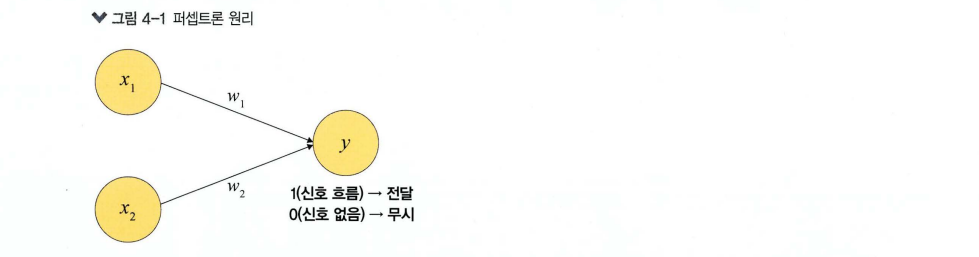

컴퓨터가 논리적으로 인식하는 방식 -> 논리 게이트로 확인
AND 게이트 / OR 게이트 / XOR 게이트

**AND 게이트**
- 모든 입력이 '1'일 때 작동함.
- 즉 입력 중 어떤 하나라도 '0'을 갖는다면 작동을 멈춤

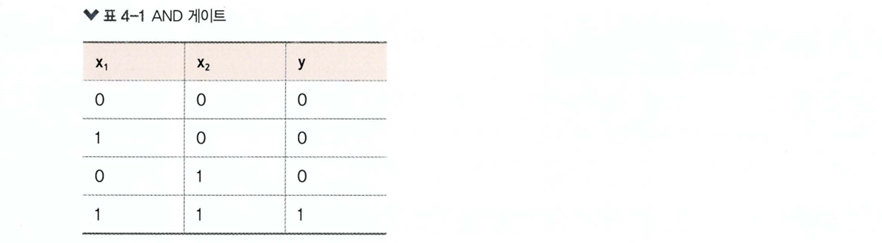

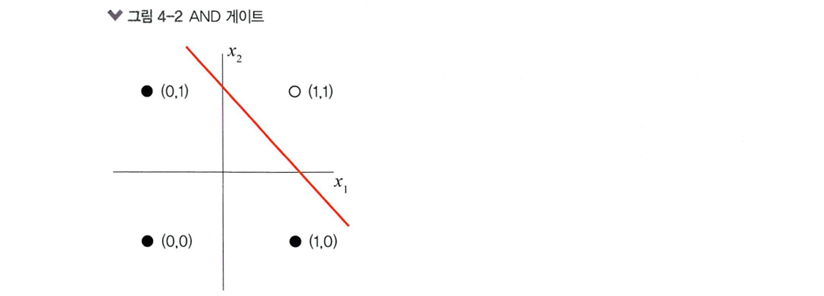

**OR 게이트**
- 입력에서 둘 중 하나만 '1'이거나 둘 다 '1'일 때 작동함.
- 즉, 입력 모두가 '0'을 갖는 경우를 제외한 나머지가 모두 작동함.

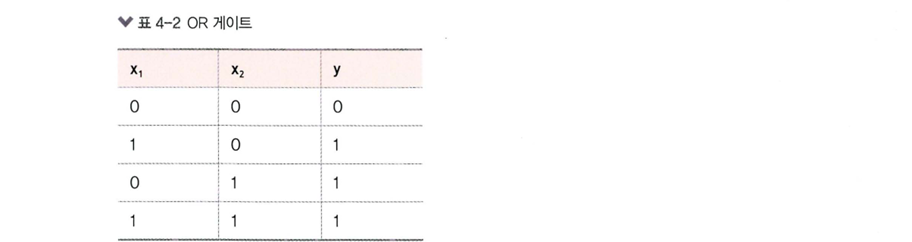

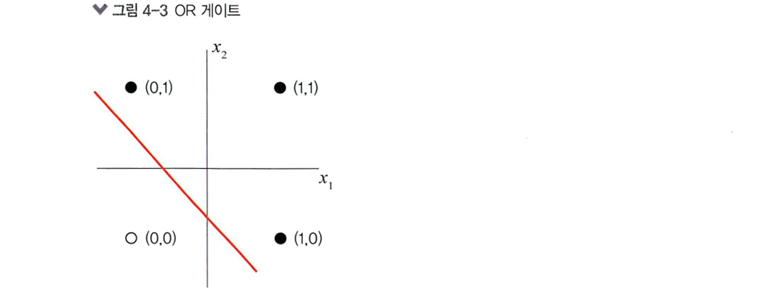

**XOR 게이트**
- 배타적 논리합이라는 용어로 입력 두 개 중 한 개만 '1'일 때 작동함.
- 데이터가 비선형적으로 분리되기 때문에 제대로 된 분류가 어려움. 즉, 단층 퍼셉트론에서 XOR에 대해서는 학습이 불가능.
    - 이를 극복하는 방안으로 입력층과 출력층 사이에 하나 이상의 중간층(은닉층)을 두어 비선형적으로 분리되는 데이터에 대해서도 학습이 가능하도록 다층 퍼셉트론을 고안함.
    - 이때 입력층과 출력층 사이에 은닉층이 여러 개 있는 신경망을 심층 신경망(딥러닝)이라고 함.

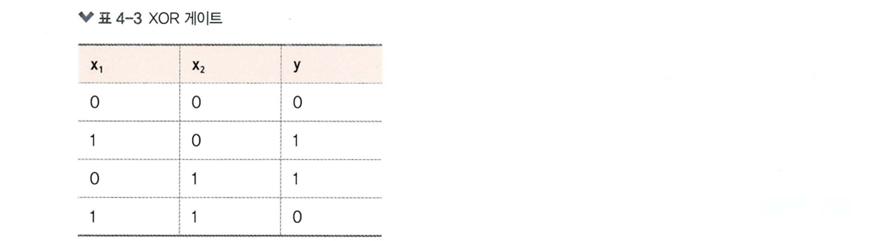

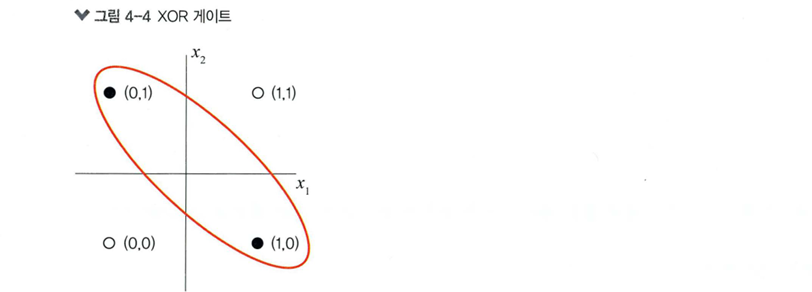

# 4.2 딥러닝 구조

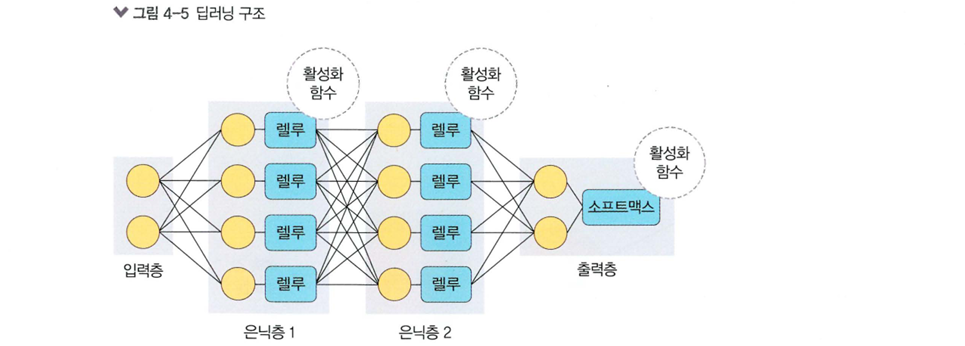

## 4.2.1 딥러닝 용어

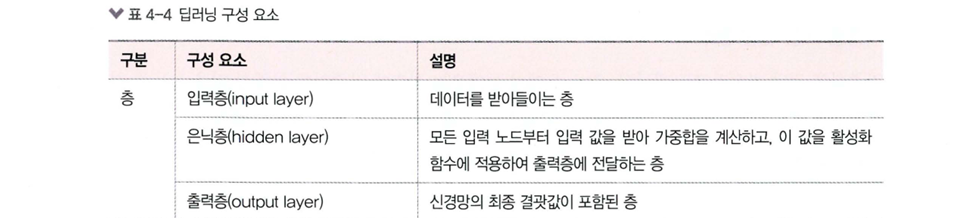

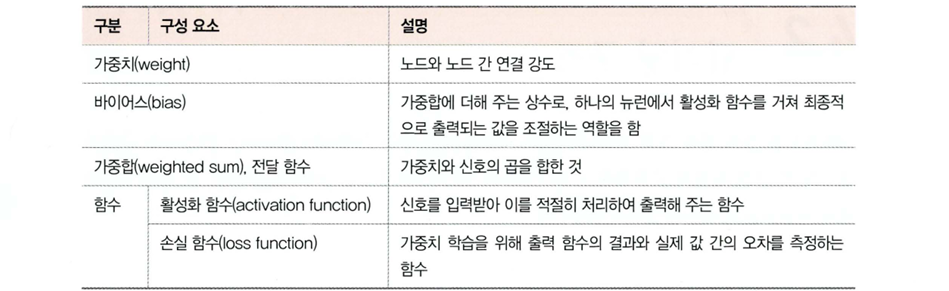

**가중치**
- 입력 값이 연산 결과에 미치는 영향력을 조절하는 요소

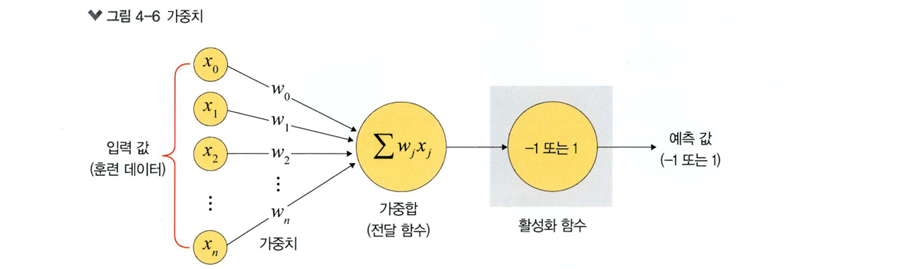

**가중합(전달 함수)**
- 각 노드에서 들어오는 신호에 가중치를 곱해서 다음 노드로 전달되는데, 이 값들을 모두 더한 합계
- 노드의 가중합이 계산되면 이 가중합을 활성화 함수로 보내기 때문에 전달 함수라고도 함.

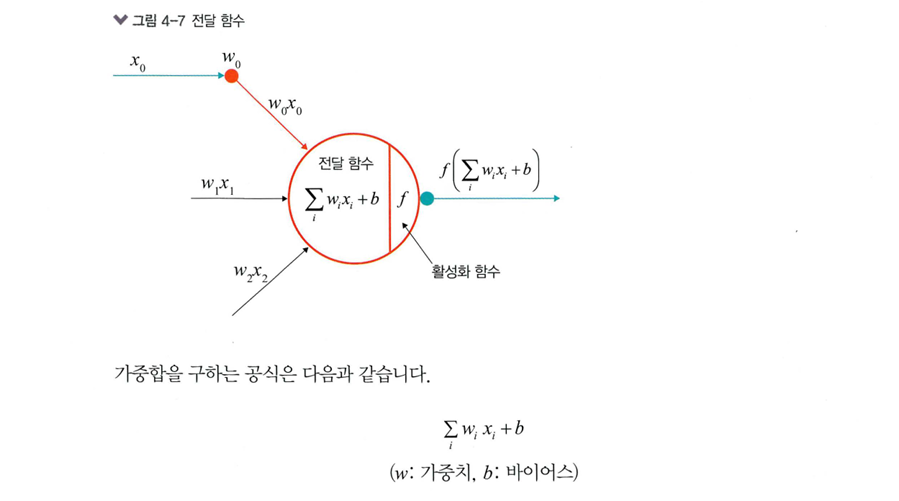

**활성화 함수**
- 전달 함수에서 전달받은 값을 출력할 때 일정 기준에 따라 출력 값을 변화시키는 비선형 함수
- 종류
    - 시그모이드(sigmoid)
    - 하이퍼볼릭 탄젠트(hyperbolic tangent)
    - 렐루(ReLU) 함수 등

> 시그모이드 함수 \
    - 선형 함수의 결과를 O~1 사이에서 비선형 형태로 변형해 줌. \
    - 주로 로지스틱 회귀와 같은 분류 문제를 확률적으로 표현하는 데 사용됨. \
    - 딥러닝 모델의 깊이가 깊어지면 기울기가 사라지는 기울기 소멸 문제가 발생하여 딥러닝 모델에서는 잘 사용하지 않음.

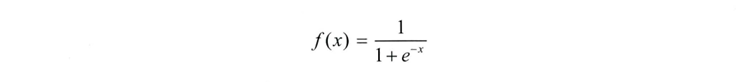

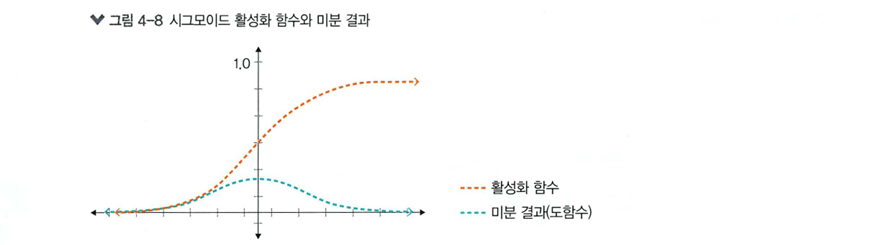

> 하이퍼볼릭 탄젠트 함수 \
    - 선형 함수의 결과를 -1~1 사이에서 비선형 형태로 변형해 줌. \
    - 시그모이드에서 결과값의 평균이 0이 아닌 양수로 편향된 문제를 해결했지만, 기울기 소멸 문제는 여전히 발생함.

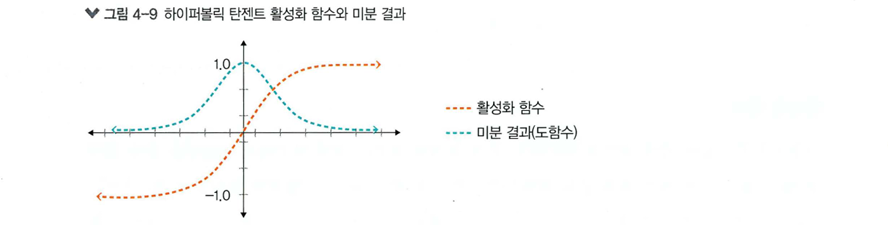

> 렐루 함수 \
    - 입력(x)이 음수일 때는 0을 출력하고, 양수일 때는 x를 출력함. \
    - 경사 하강법에 영향을 주지 않아 학습이 빠르고 기울기 소멸 문제가 발생하지 않음. \
    - 일반적으로 은닉층에서 사용되며, 하이퍼볼릭 탄젠트 함수 대비 학습 속도가 6배 빠름. \
    - 음수값을 입력받으면 항상 0을 출력 -> 학습능력이 감소하는데, 이를 해결하고자 리키 렐루(Leaky ReLU) 함수 사용.

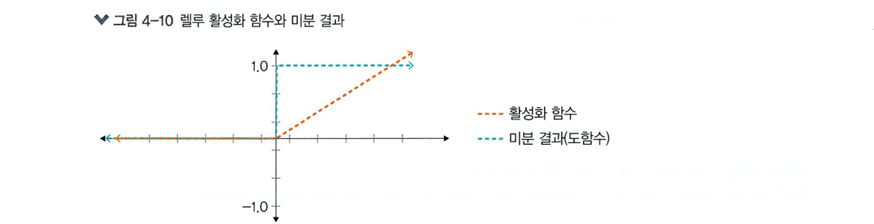

> 리키 렐루 함수 \
    - 입력 값이 음수이면 0이 아닌 0.001처럼 매우 작은 수를 반환함. \
    - 입력 값이 수렴하는 구간이 제거되어 렐루 함수를 사용할 때 생기는 문제를 해결 가능.

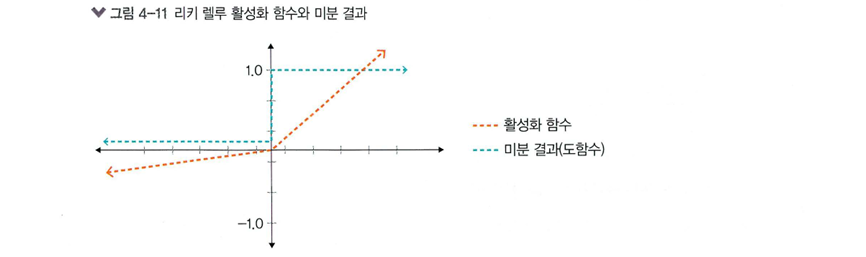

> 소프트맥스 함수 \
    - 입력 값을 0~1 사이에 출력되도록 정규화하여 출력 값들의 총합이 항상 1이 되도록 함. \
    - 보통 딥러닝에서 출력 노드의 활성화 함수로 많이 사용됨.

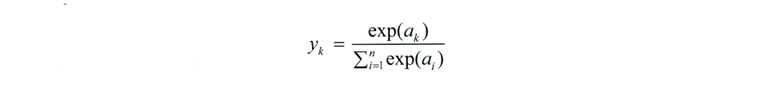

    - exp(ak), exp(ai): 지수 함수
    - n: 출력층의 뉴런 개수
    - yk: 그중 k번째 출력

```python
# 렐루 함수와 소프트맥스 함수를 파이토치에서 구현

class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # 은닉층
        self.relu = torch.nn.ReLU(inplace=True)
        self.out = torch.nn.Linear(n_hidden, n_output)       # 출력층
        self.softmax = torch.nn.Softmax(dim=n_output)
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)        # 은닉층을 위한 렐루 활성화 함수
        x = self.out(x)
        x = self.softmax(x)     # 출력층을 위한 소프트맥스 활성화 함수
        return x
```

**손실 함수**
- 추정치가 실제와 얼마나 차이가 나는지 평가하는 지표
- 이 값이 클수록 많이 틀렸다는 의미이고, '0'에 가까우면 완벽하게 추정했다는 의미.
- 대표적인 손실 함수
    - 평균 제곱 오차
    - 크로스 엔트로피 오차

> 평균 제곱 오차(MSE) \
    - 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 것 \
    - 작을 수록 예측력이 좋음 \
    - 회귀에서 손실 함수로 주로 사용됨

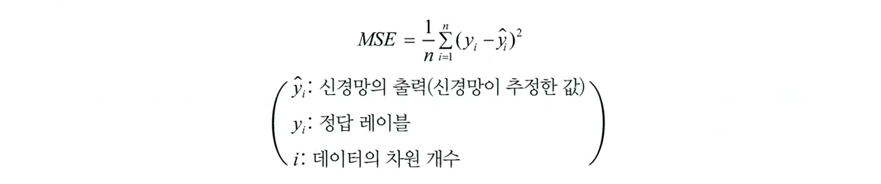

```python
# 파이토치에서 MSE 사용

import torch

loss_fn = torch.nn.MSELoss(reduction='sum')
y_pred = model(x)
loss = loss_fn(y_pred, y)
```

> 크로스 엔트로피 오차(CEE) \
    - 문제에서 원-핫 인코딩했을 때 사용할 수 있는 오차계산법 \
    - 두 개의 확률 분포 차이 이용 -> 시그모이드의 영향을 덜 받아서 평균 제곱 오차보다 학습 속도가 빠름.

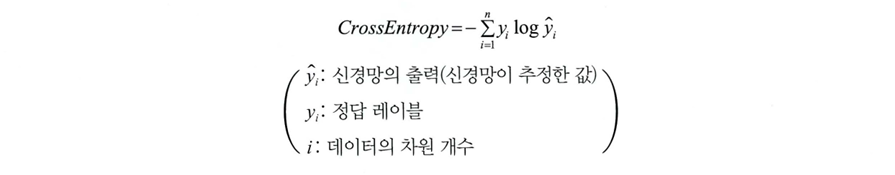

```python
# 파이토치에서 크로스 엔트로피 오차 사용

loss = nn.CrossEntropyLoss()
input = torch.randn(5, 6, requires_grad=True)
target = torch.empty(3, dtype=torch.long).random_(5)
output = loss(input, target)
output.backward()
```

## 4.2.2 딥러닝 학습

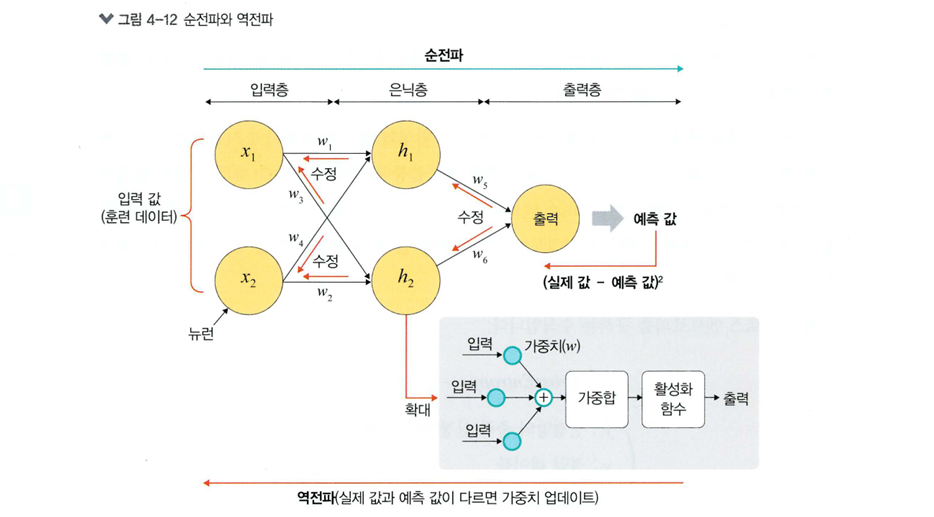

**순전파**
- 모든 뉴런이 이전 층의 뉴런에서 수신한 정보에 변환(가중합 및 활성화 함수)을 적용하여 다음 층(은닉층)의 뉴런으로 전송하는 방식
- 모든 뉴런이 계산을 완료하면 그 예측 값은 최종 층(출력층)에 도달하게 됨.

- 그 다음 손실 함수로 네트워크의 예측 값과 실제 값의 차이(손실 오차)를 추정함.

**역전파**
- 손실 함수 비용이 0에 가깝도록 하기 위해 모델이 훈련을 반복하면서 가중치 조정. 손실이 계산되면 그 정보는 역으로 전파(출력층 -> 은닉층 -> 입력층)되기 때문에 역전파라고 함


> 예측 값과 실제 값 차이를 각 뉴런의 가중치로 미분한 후 기존 가중치 값에서 뺌. 이 과정을 출력층→은닉층→입력층 순서로 모든 뉴런에 대해 진행하여 계산된 각 뉴런 결과를 또다시 순전파의 가중치 값으로 사용.

## 4.2.3 딥러닝의 문제점과 해결 방안

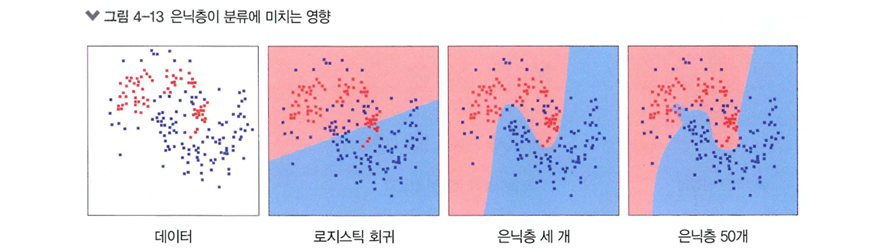

    활성화 함수가 적용된 은닉층 개수가 많을수록 데이터 분류가 잘되고 있음.

**은닉층이 많을수록 생기는 세 가지 문제점**
- 과적합 문제
- 기울기 소멸 문제
- 성능이 나빠지는 문제

> 과적합 문제 \
    - 훈련 데이터에 대해 과하게 학습하여 실제 데이터에 대한 오차가 증가하는 현상을 의미. \
    - 해결 방법 -> 드롭아웃(dropout): 학습 과정 중 임의로 일부 노드들을 학습에서 제외시킴

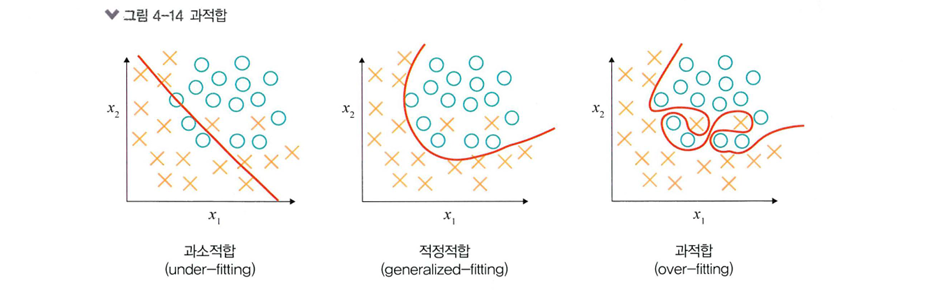

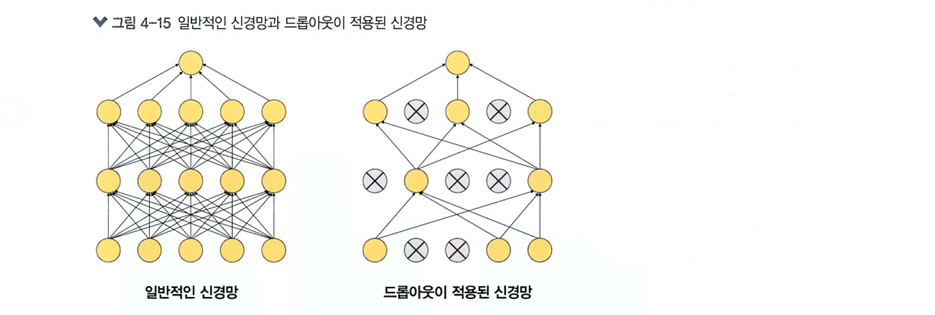

In [6]:
# 파이토치에서 드롭아웃 구현

class DropoutModel(torch.nn.Module):
    def __init__(self):
        super(DropoutModel, self).__init__()
        self.layer1 = torch.nn.Linear(784, 1200)
        self.dropout1 = torch.nn.Dropout(0.5)    # 50%의 노드를 무작위로 선택하여 사용X
        self.layer2 = torch.nn.Linear(1200, 1200)
        self.dropout2 = torch.nn.Dropout(0.5)
        self.layer3 = torch.nn.Linear(1200, 10)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        return self.layer3(x)

> 기울기 소멸 문제 \
    - 출력층에서 은닉층으로 전달되는 오차가 크게 줄어들어 학습이 되지 않는 현상. \
    - 해결 방법 -> 시그모이드나 하이퍼볼릭 탄젠트 대신 렐루 활성화 함수를 사용.

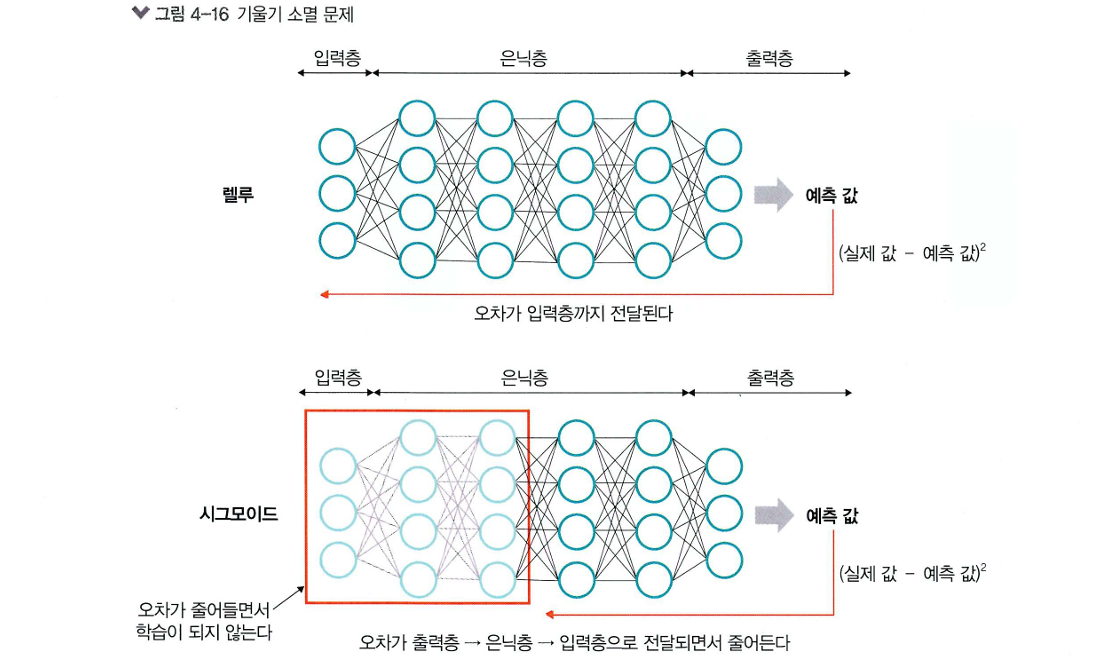

> 성능이 나빠지는 문제 \
    - 기울기가 낮은 쪽으로 계속 이동시키는 과정에서 성능이 나빠지는 문제 \
    - 해결 방법: 확률적 경사하강법, 미니 배치 경사하강법 사용.


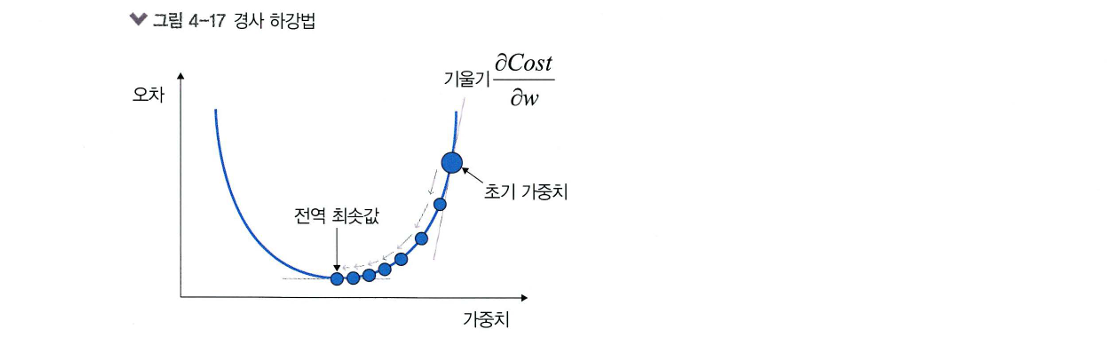

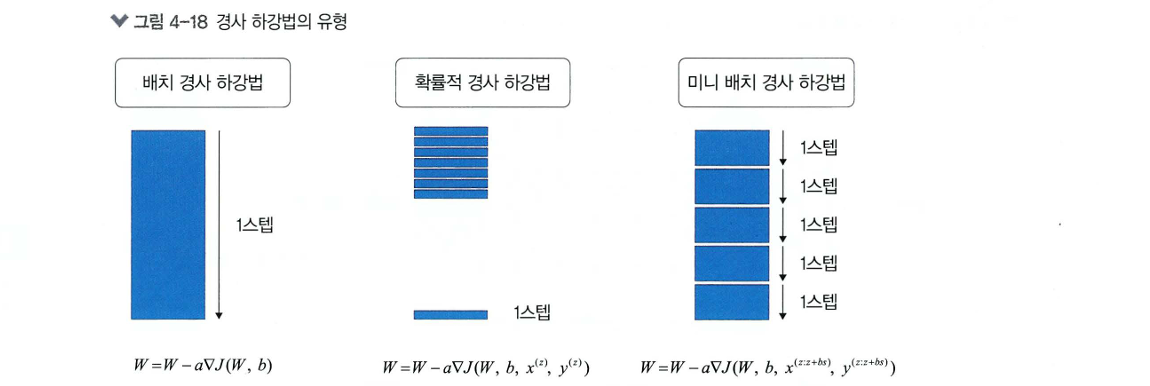

**경사 하강법 유형**
- 배치 경사 하강법
- 확률적 경사 하강법
- 미니 배치 경사 하강법

> 배치 경사 하강법 \
    - 전체 데이터셋에 대한 오류를 구한 후 기울기를 한 번만 계산하여 모델의 파라미터를 업데이트하는 방법 \
    - 한 스텝에 모든 훈련 데이터셋을 사용하므로 학습이 오래 걸림 -> 개선한 방법이 확률적 경사 하강법

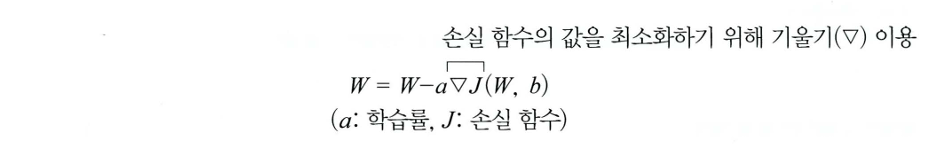

> 확률적 경사 하강법 \
    - 임의로 선택한 데이터에 대해 기울기를 계산하는 방법 \
    - 적은 데이터를 사용하므로 빠른 계산이 가능함.\
    - 파라미터 변경 폭이 불안정하고 때로는 배치 경사 하강법보다 정확도가 낮을 수 있지만 속도가 빠르다는 장점이 있음.

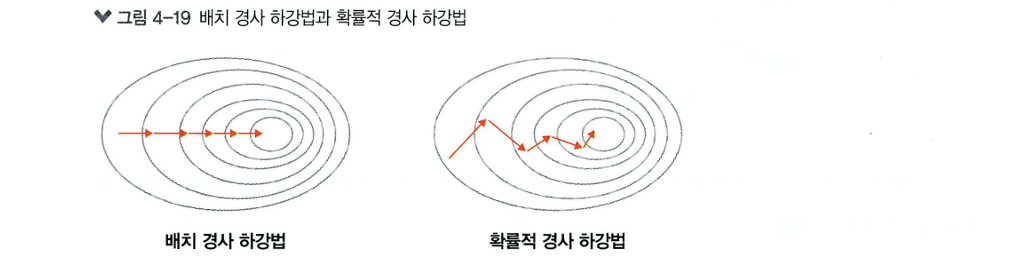

> 미니 배치 경사 하강법 \
    - 전체 데이터셋을 미니 배치(mini-batch) 여러 개로 나누고, 미니 배치 한 개마다 기울기를 구한 후 그것의 평균 기울기를 이용하여 모델을 업데이트해서 학습하는 방법. \
    - 전체 데이터를 계산하는 것보다 빠르며 확률적 경사 하강법보다 안정적

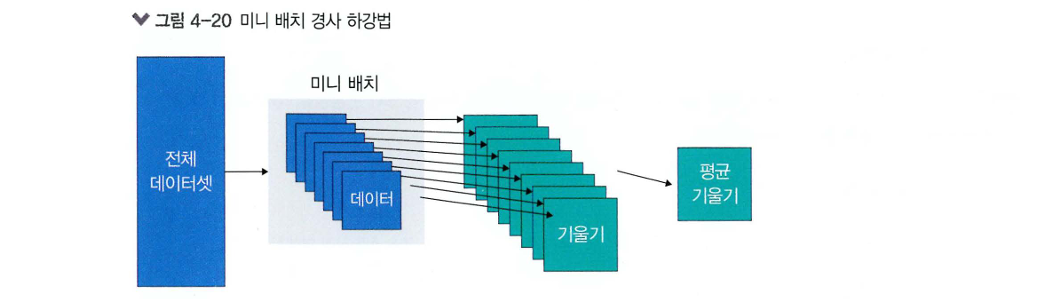

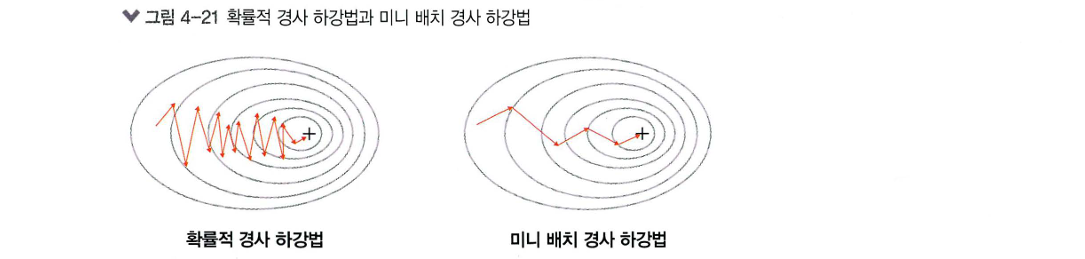

    다음 그림의 오른쪽과 같이 파라미터 변경 폭이 확률적 경사 하강법에 비해 안정적이면서 속도도 빠름.

```python
# 파이토치에서 미니 배치 경사 하강법 구현

class CustomDataset(Dataset):
    def __init__(self):
        self.x_data = [[1,2,3], [4,5,6], [7,8,9]]
        self.y_data = [[12], [18], [11]]
        def __len__(self):
            return len(self.x_data)
        def __getitem__(self, idx):
            x = torch.FloatTensor(self.x_data[idx])
            y = torch.FloatTensor(self.y_data[idx])
            return x, y
dataset = CustomDataset()
dataloader = DataLoader(dataset,  # 데이터셋
                        batch_size=2,  # 미니 배치 크기로 2의 제곱수를 사용하겠다는 의미
                        shuffle=True)  # 데이터를 불러올 때마다 랜덤으로 섞어서 가져옴
```

---

**NOTE 옵티마이저**

확률적 경사 하강법의 따라미터 변경 폭이 불안정한 문제를 해결하기 위해 학습 속도와 운동료를 조정히는 옵티마이저(optimizer)를 적용.

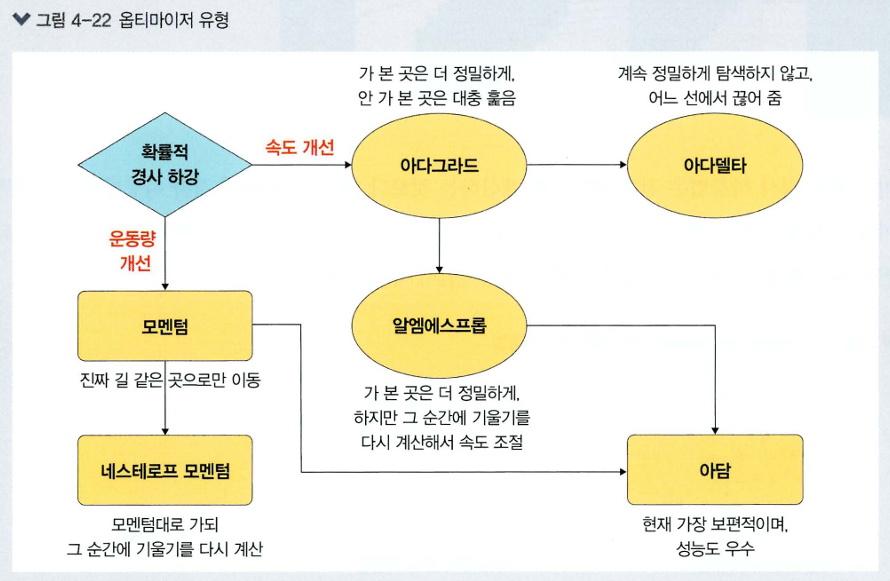

- 속도를 조정하는 방법
    - 아다그라드(Adagrad. Adaptive gradient)
        - 변수(가중치)의 업데이트 횟수에 따라 학습률을 조정하는 방법
    - 아다델타(Adadelta, Adaptive delta)
        - 아다그라드에서 G값이 커짐에 따라 학습이 멈추는 문제를 해결하기 위해 등장한 방법
    - 알엠에스프롭(RMSProp)
        - 아다그라드의 G(i) 값이 무한히 커지는 것을 방지하고자 제안된 방법
- 운동량을 조정하는 방법
    - 모멘텀(Momentum)
        - 경사 하강법처럼 매번 기울기를 구하지만, 가중치를 수정하기 전에 이전 수정 방향을 참고하여 같은 방향으로 일정한 비율만 수정하는 방법
    - 네스테로프 모멘텀(Nesterov Accelerated Gradient, NAG)
        - 모멘텀 값과 기울기 값이 더해져 실제 값을 만드는 기존 모멘텀과 달리 모멘텀 값이 적용된 지점에서 기울기 값을 계산.
- 속도와 운동량에 대한 혼용 방법
    - 아담(Adam, Adaptive Moment Estimation)
        - 모멘텀과 알멤에스프롭의 장점을 결합한 경사 하강법

## 4.2.4 딥러닝을 사용할 때 이점

**특성 추출**
-  데이터의 특징을 찾아내고, 이를 토대로 데이터를 벡터로 변환하는 작업
- 딥러닝에서는 이러한 특성 추출 과정을 알고리즘에 통합시킴.

**빅데이터의 효율적 활용**
- 딥러닝에서는 특성 추출을 알고리즘에 통합.
- 딥러닝 학습을 이용한 특성 추출은 데이터 사례가 많을수록 성능이 향상됨.

# 4.3 딥러닝 알고리즘

- 딥러닝 알고리즘은 심층 신경망을 사용함.
- 머신 러닝 알고리즘처럼 목적에 따라 분류됨
    - 합성곱 신경망(CNN)
    - 순환 신경망(RNN)
    - 제한된 볼츠만 머신(RBM)
    - 심층 신뢰 신경망(DBN)

## 4.3.1 심층 신경망(DNN)
- 입력층과 출력층 사이에 다수의 은닉층을 포함하는 인공 신경망
- 다수의 은닉층을 추가했기 때문에 별도의 트릭 없이 비선형 분류가 가능
- 연산량이 많고 기울기 소멸 문제 등이 발생할 수 있음
    - -> 드롭아웃, 렐루 함수, 배치 정규화 등을 적용하여 해결

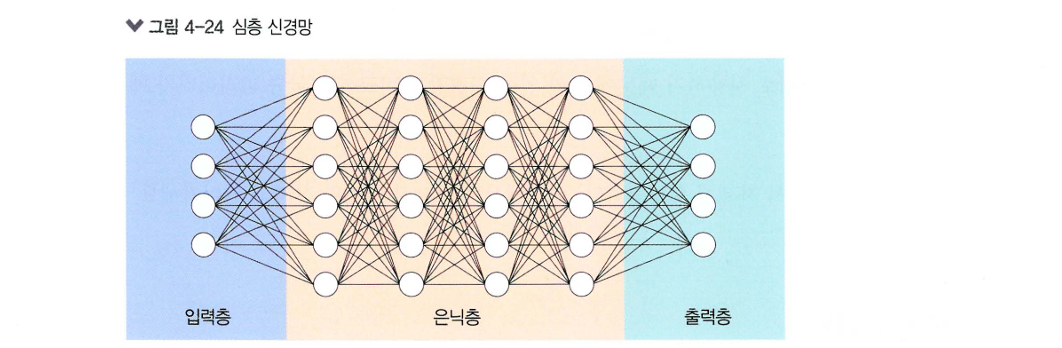

## 4.3.2 합성곱 신경망
- 합성곱층과 풀링층을 포함하는 이미지 처리 기능이 좋은 인공 신경망 알고리즘

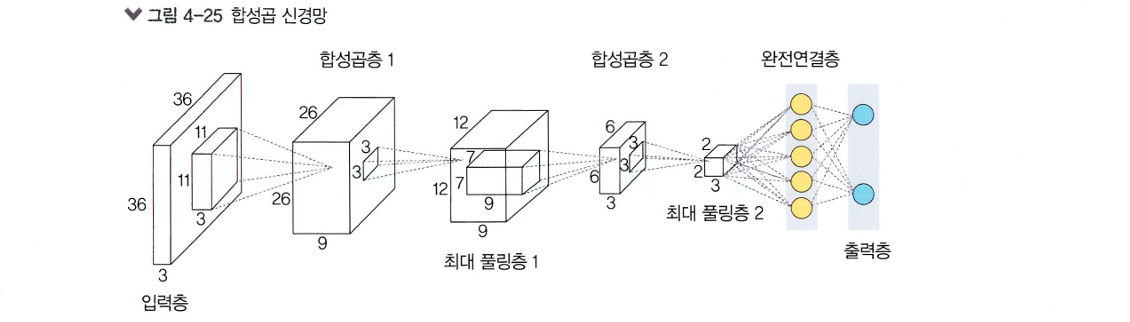

**대표적인 합성곱 신경망**
- LeNet-5
- AlexNet

**층을 더 깊게 쌓은 신경망**
- VGG
- GoogLeNet
- ResNet
---
**기존 신경망과 비교한 차별성**
- 각 층의 입출력 형상을 유지
- 이미지의 공간 정보를 유지하면서 인접 이미지와 차이가 있는 특징을 효과적으로 인식
- 복수 필터로 이미지의 특징을 추출하고 학습
- 추출한 이미지의 특징을 모으고 강화하는 풀링층 존재
- 필터를 공유 파라미터로 시용하기 때문에 일반 인공 신경망과 비교하여 학습 파라미터가 매우 적음

## 4.3.3 순환 신경망
- 시계열 데이터와 같은 시간 흐름에 따라 변화하는 데이터를 학습하기 위한 인공 신경망

**순환 신경망의 특징**
- 시간성을 가진 데이터가 많음
- 시간성 정보를 이용하여 데이터의 특징을 잘 다룸
- 시간에 따라 내용이 변하므로 데이터는 동적이고 길이가 가변적임
- 매우 긴 데이터를 처리하는 연구가 활발히 진행되고 있음

- 기울기 소멸 문제 -> 메모리 개념을 도입한 LSTM 사용하여 해결

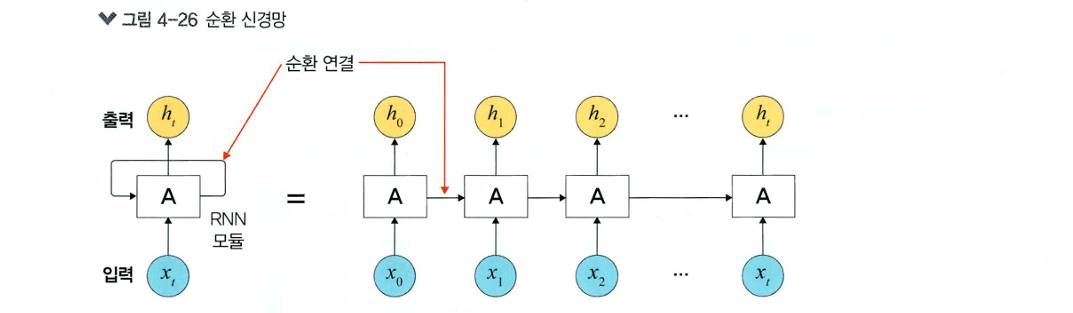

## 4.3.4 제한된 볼츠만 머신
- 볼츠만 머신: 가시층과 은닉층으로 구성된 모델
- 제한된 볼츠만 머신: 가시층과 가시층, 은닉층과 은닉층 사이에 연
결은 없는 볼츠만 머신

**제한된 볼츠만 머신의 특징**
- 차원 감소, 분류, 선형 회귀 분석, 협업 필터링, 특성 값 학습, 주제 모델링에 사용함.
- 기울기 소멸 문제를 해결하기 위해 사전 학습 용도로 활용 가능
- 심층 신뢰 신경망(DBN)의 요소로 활용됨

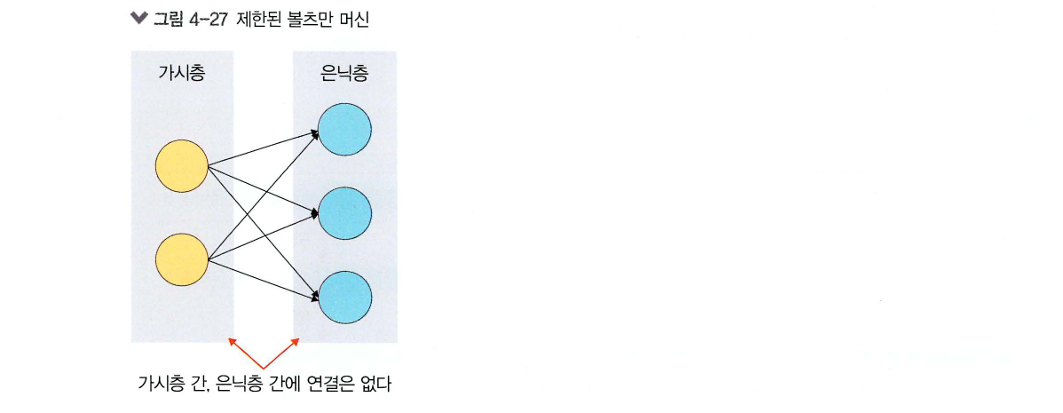

## 4.3.5 심층 신뢰 신경망
-  제한된 볼츠만 머신을 블록처럼 여러 층으로 쌓은 형태로 연결된 신경망
- 사전 훈련된 제한된 볼츠만 머신을 층층이 쌓아 올린 구조로 레이블이 없는 데이터에 대한 비지도 학습이 가능함.

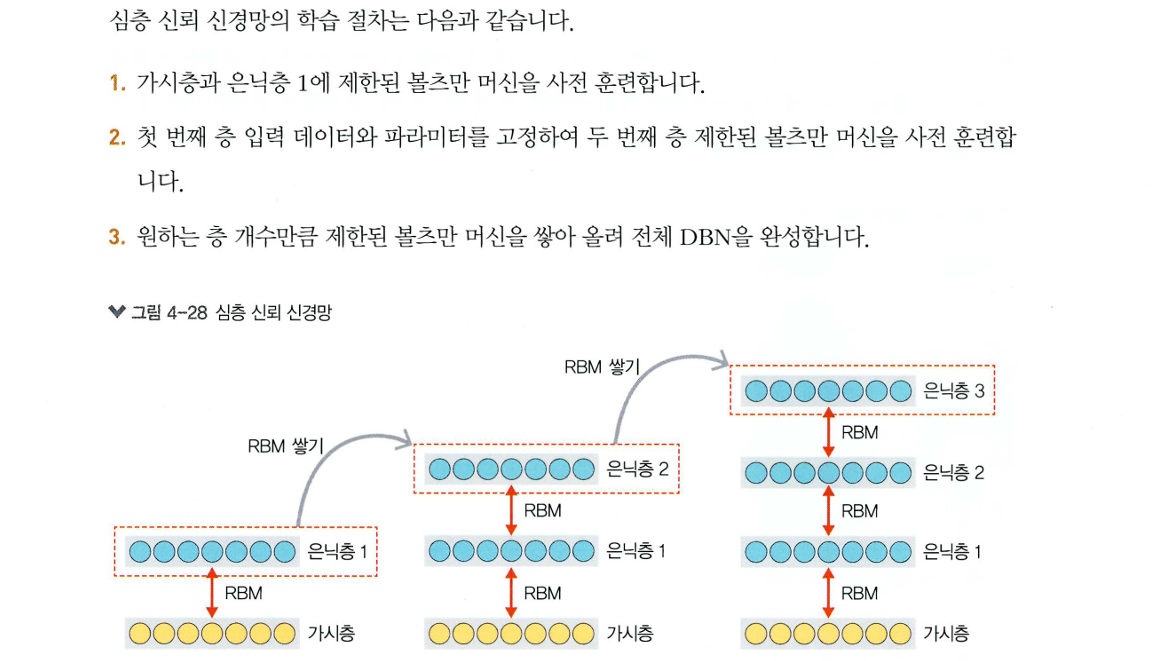

**심층 신뢰 신경망의 특징**
- 순차적으로 심층 신뢰 신경망을 학습시켜 가면서 계층적 구조를 생성함.
- 비지도학습으로 학습
- 위로 올라갈수록 추상적 특성을 추출함.
- 학습된 가중치를 다층 퍼셉트론의 가중치 초깃값으로 사용함.